C:\Users\ilaki\AppData\Local\Temp\ipykernel_27508\3506576832.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


000000482829.jpg: Foreground ratio=0.356 | Pseudo Dice=0.525


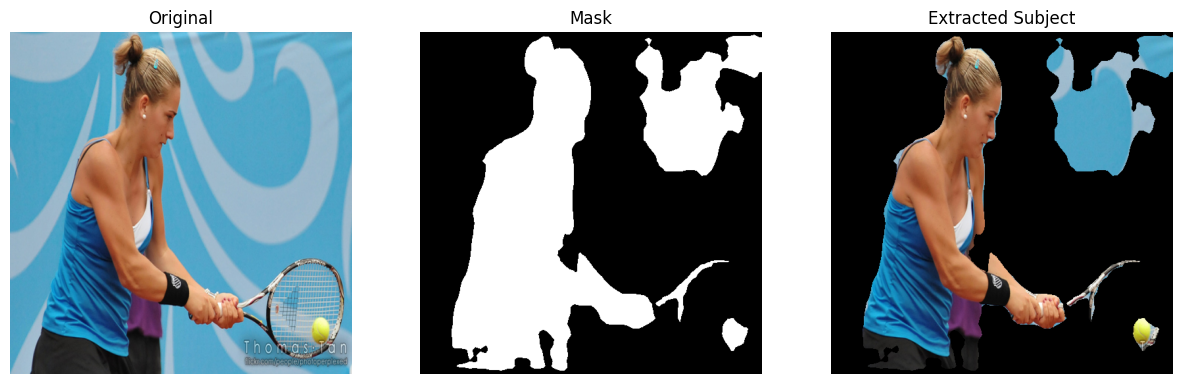

000000223348.jpg: Foreground ratio=0.744 | Pseudo Dice=0.853


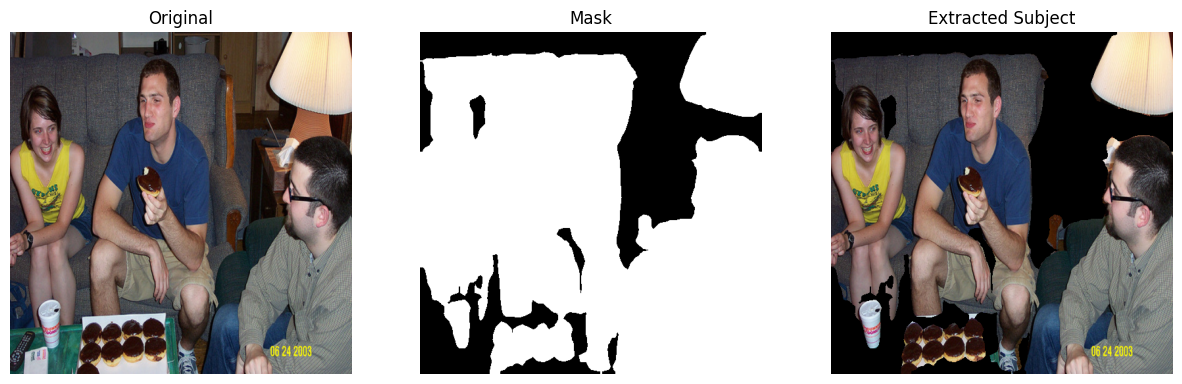

000000275245.jpg: Foreground ratio=0.050 | Pseudo Dice=0.096


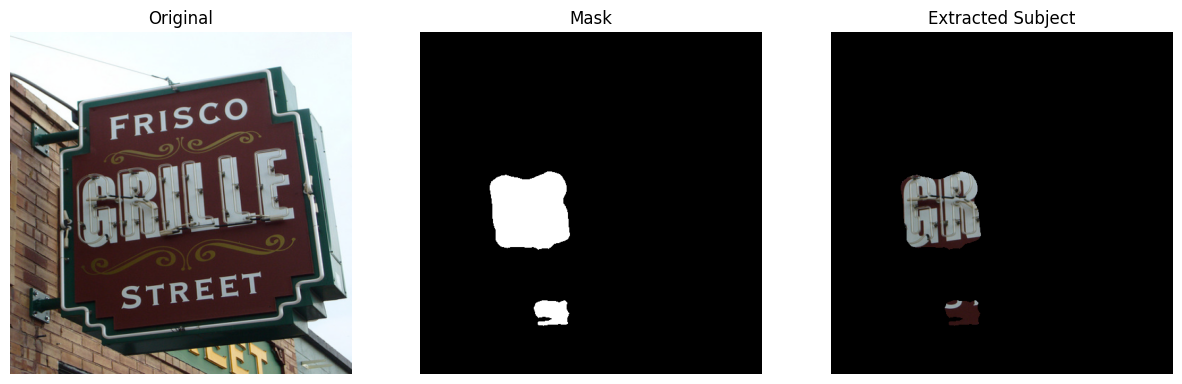

000000571677.jpg: Foreground ratio=0.217 | Pseudo Dice=0.356


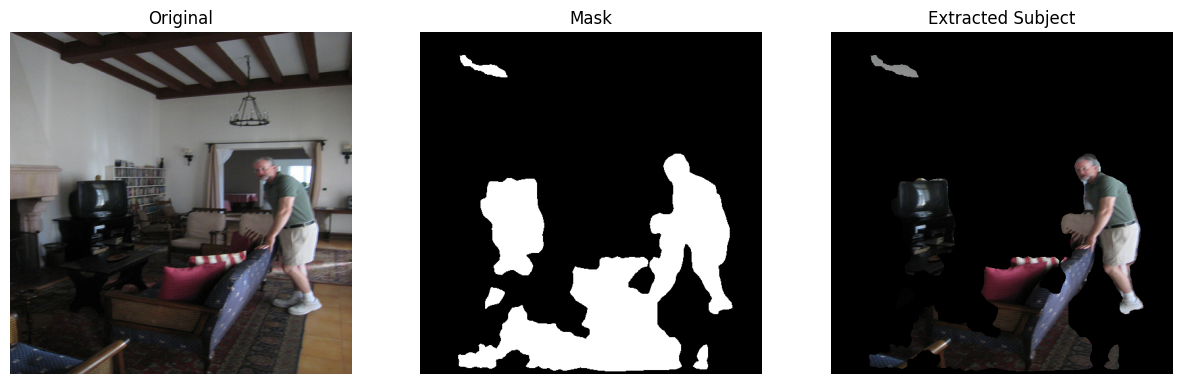

000000561630.jpg: Foreground ratio=0.208 | Pseudo Dice=0.345


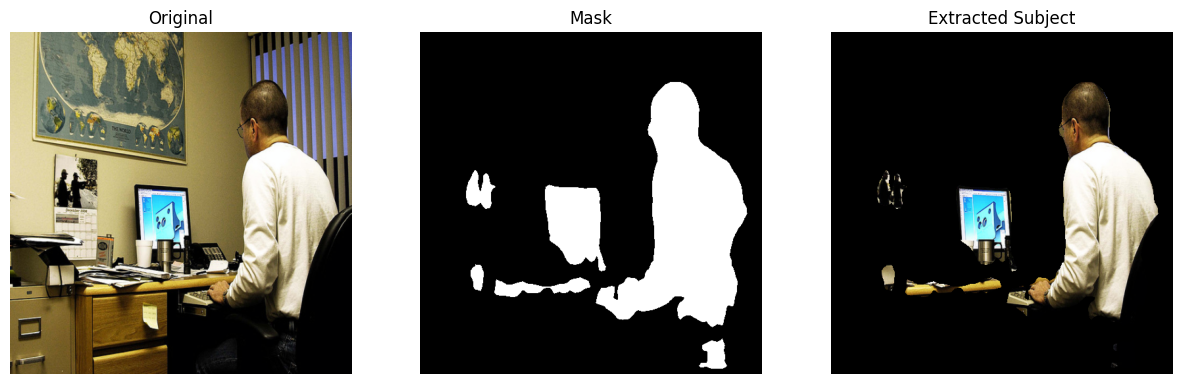

000000335507.jpg: Foreground ratio=0.483 | Pseudo Dice=0.651


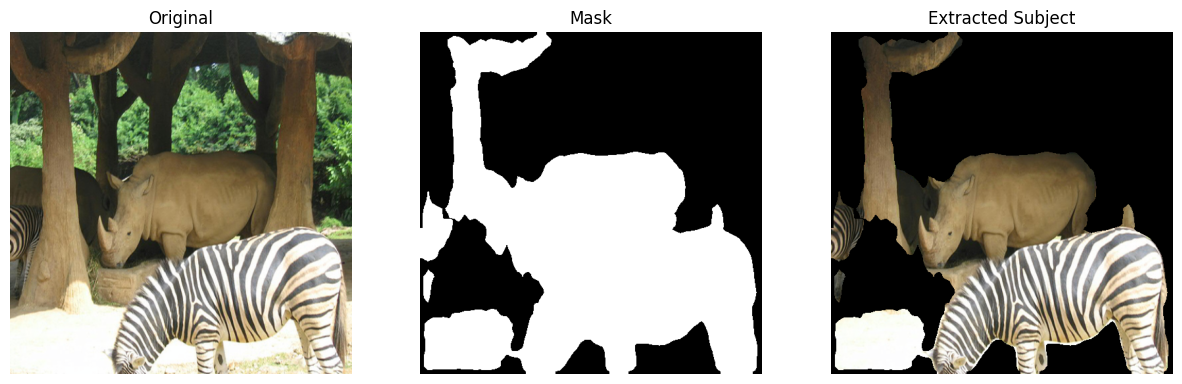

000000077426.jpg: Foreground ratio=0.605 | Pseudo Dice=0.754


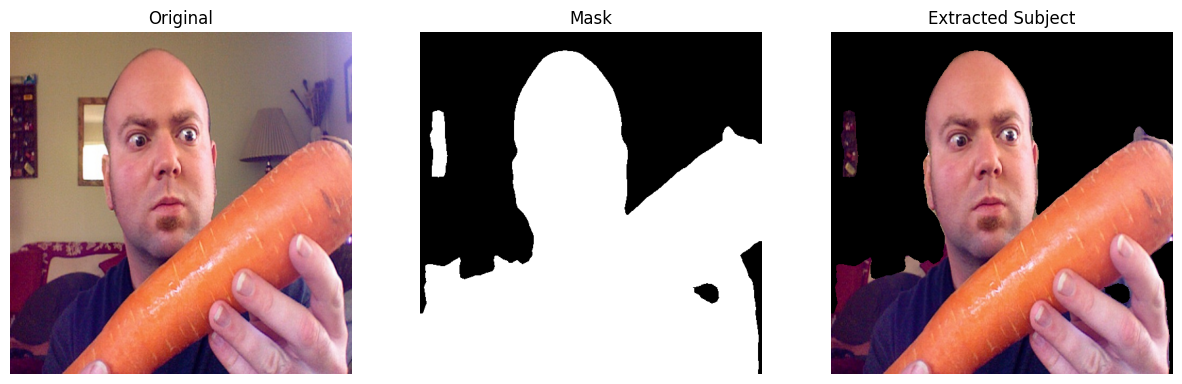

000000150089.jpg: Foreground ratio=0.144 | Pseudo Dice=0.251


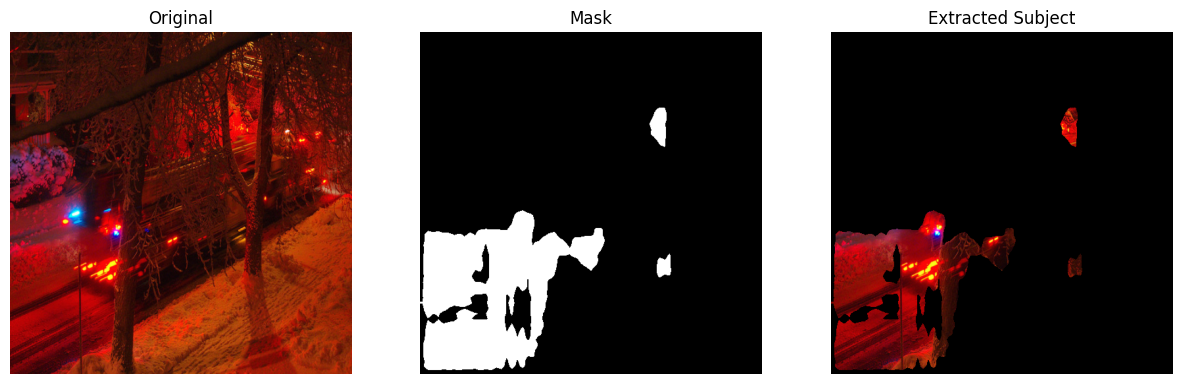

000000297868.jpg: Foreground ratio=0.528 | Pseudo Dice=0.691


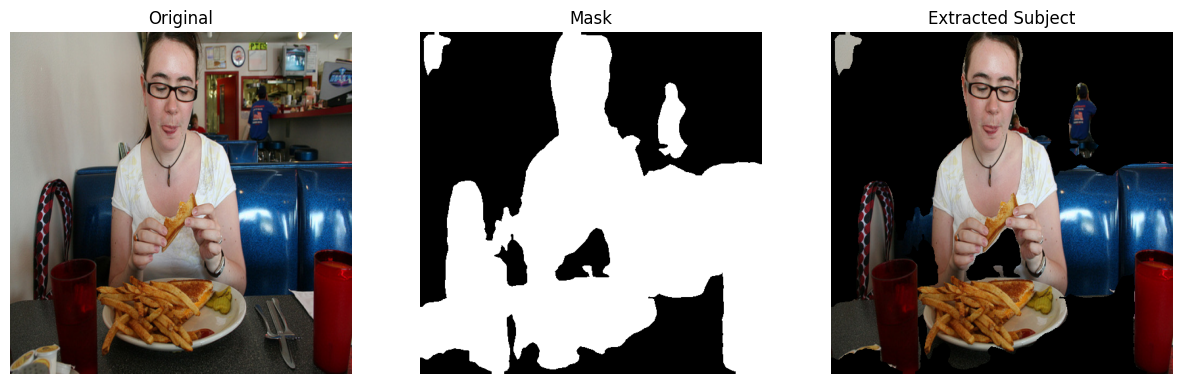

000000554952.jpg: Foreground ratio=0.418 | Pseudo Dice=0.590


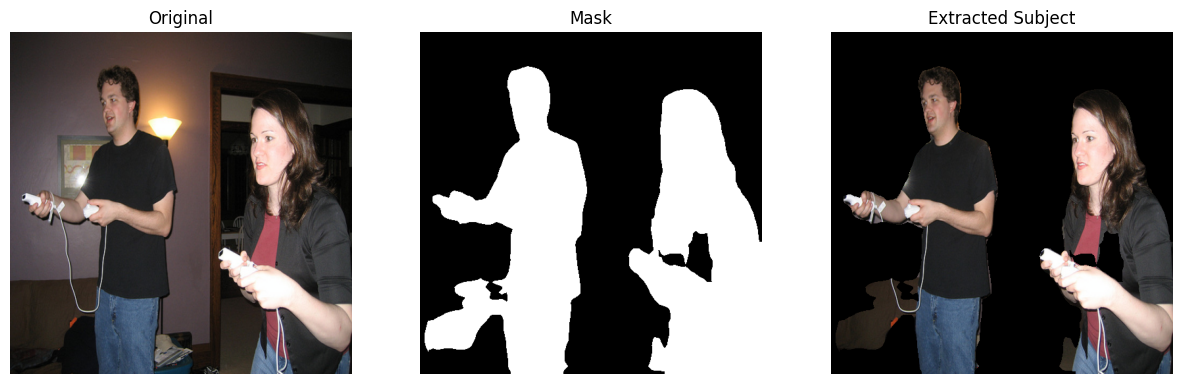

000000045058.jpg: Foreground ratio=0.469 | Pseudo Dice=0.638


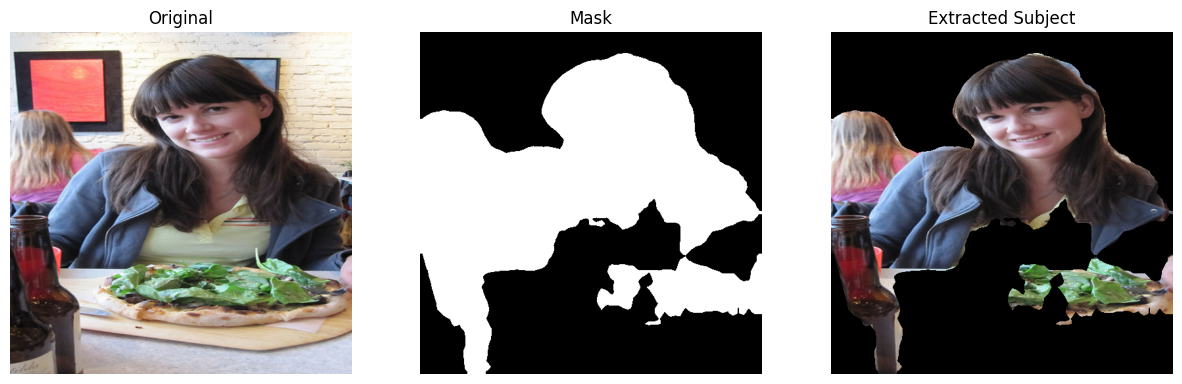

000000345960.jpg: Foreground ratio=0.382 | Pseudo Dice=0.553


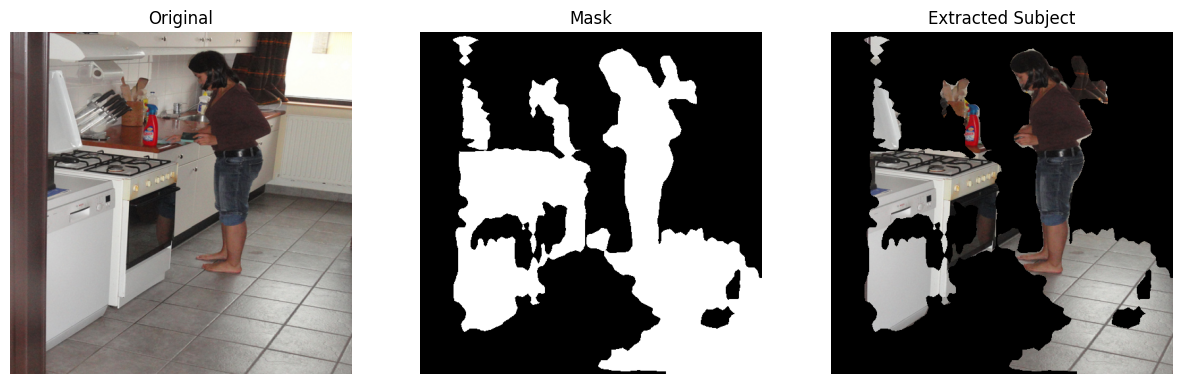

000000465550.jpg: Foreground ratio=0.574 | Pseudo Dice=0.730


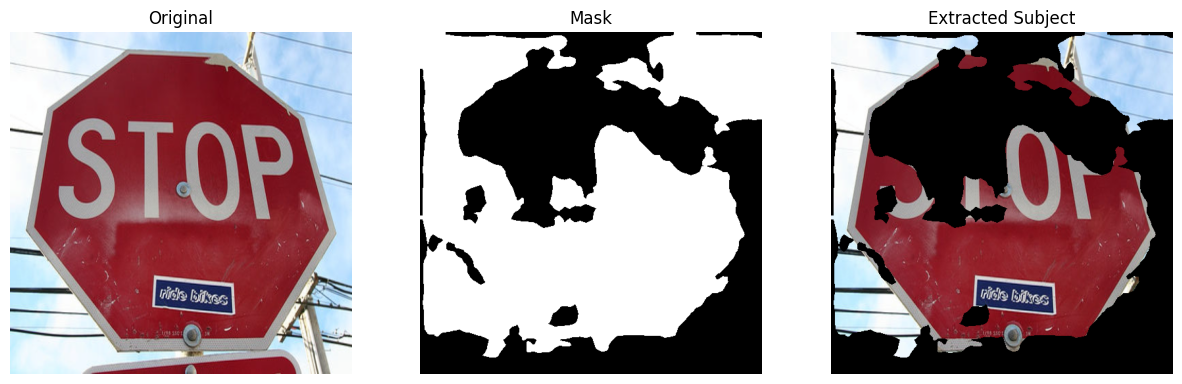

000000139712.jpg: Foreground ratio=0.069 | Pseudo Dice=0.128


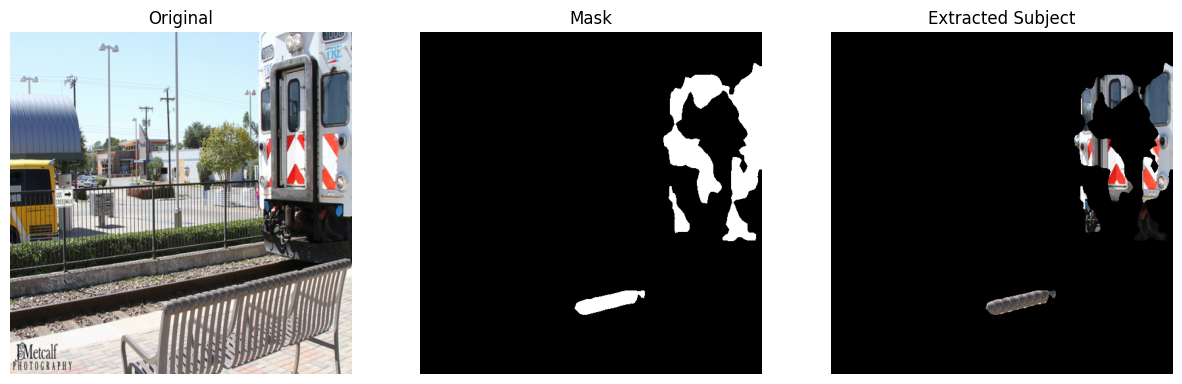

000000436145.jpg: Foreground ratio=0.320 | Pseudo Dice=0.485


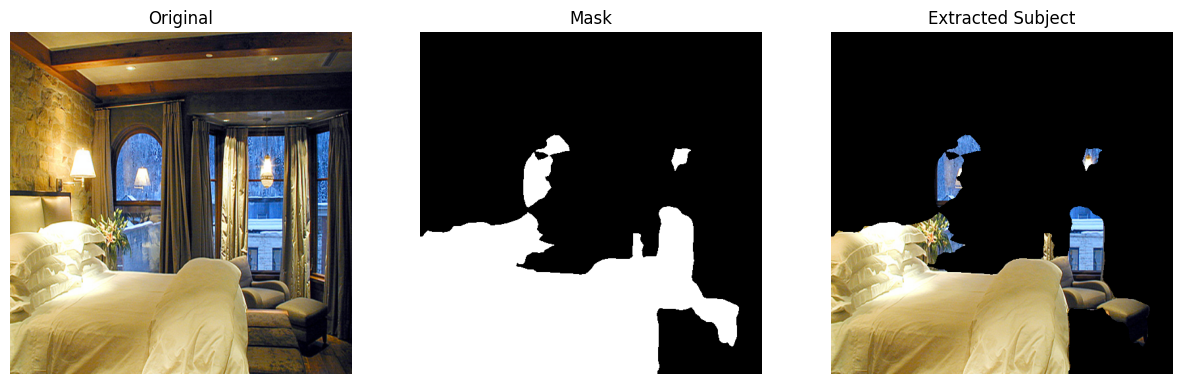


==== New Batch Metrics ====
Average foreground pixel ratio: 0.371
Average pseudo Dice: 0.510


In [4]:
import torch
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
from skimage import measure, morphology
from torchvision.models.segmentation import deeplabv3_resnet50


model_path = r"C:\Users\ilaki\Desktop\VISON_AI\coco2017\deeplabv3_resumed_epoch30.pth"
new_images_dir = r"C:\Users\ilaki\Desktop\VISON_AI\coco2017\testing images in internet"
output_dir = r"C:\Users\ilaki\Desktop\VISON_AI\new_outputs"
os.makedirs(output_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


num_classes = 2
model = deeplabv3_resnet50(num_classes=num_classes, aux_loss=False)
checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint, strict=False)
model.to(device)
model.eval()


transform = transforms.Compose([
    transforms.Resize((520, 520)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def denormalize(tensor):
    img = tensor.clone().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    return np.clip(img, 0, 1)

def extract_subject(image, mask):
    masked = image.copy()
    masked[mask == 0] = 0
    return masked

def pseudo_accuracy(mask):
    return mask.sum() / mask.size

def pseudo_dice(mask):
    fg = mask.sum()
    bg = mask.size - fg
    return (2 * fg) / (2 * fg + bg) if (2 * fg + bg) > 0 else 0.0

def postprocess_mask(prob_mask, threshold=0.5, min_size=500):
    mask = (prob_mask > threshold).astype(np.uint8)
    mask = morphology.remove_small_objects(mask.astype(bool), min_size=min_size)
    mask = morphology.remove_small_holes(mask, area_threshold=min_size)
    return mask.astype(np.uint8)


all_images = [f for f in os.listdir(new_images_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
sample_images = random.sample(all_images, min(15, len(all_images)))

foreground_ratios = []
dice_scores = []

for img_name in sample_images:
    img_path = os.path.join(new_images_dir, img_name)
    img = Image.open(img_path).convert("RGB")
    img_tensor = transform(img).to(device).unsqueeze(0)

    with torch.no_grad():
        output = model(img_tensor)['out']
        prob_mask = torch.softmax(output, dim=1)[0,1].cpu().numpy()  # class 1 probability

    pred_bin = postprocess_mask(prob_mask, threshold=0.5, min_size=500)

    acc_ratio = pseudo_accuracy(pred_bin)
    dsc = pseudo_dice(pred_bin)
    foreground_ratios.append(acc_ratio)
    dice_scores.append(dsc)

    print(f"{img_name}: Foreground ratio={acc_ratio:.3f} | Pseudo Dice={dsc:.3f}")

    extracted = extract_subject(denormalize(img_tensor.squeeze()), pred_bin)
    plt.imsave(os.path.join(output_dir, img_name), extracted)

    fig, axs = plt.subplots(1,3, figsize=(15,5))
    axs[0].imshow(denormalize(img_tensor.squeeze()))
    axs[0].set_title("Original")
    axs[0].axis("off")

    axs[1].imshow(pred_bin, cmap="gray")
    axs[1].set_title("Mask")
    axs[1].axis("off")

    axs[2].imshow(extracted)
    axs[2].set_title("Extracted Subject")
    axs[2].axis("off")
    plt.show()


avg_ratio = np.mean(foreground_ratios)
avg_dice = np.mean(dice_scores)
print("\n==== New Batch Metrics ====")
print(f"Average foreground pixel ratio: {avg_ratio:.3f}")
print(f"Average pseudo Dice: {avg_dice:.3f}")
